In [1]:
# Part 4: Data Visualization & Machine Learning
# Task 1 - Data Exploration with Pandas

import pandas as pd
import numpy as np

print("\n" + "="*80)
print("PART 4 - DATA VISUALIZATION & MACHINE LEARNING")
print("Task 1 - Data Exploration with Pandas")
print("="*80 + "\n")

# Load the dataset
df = pd.read_csv("students.csv")

print("Dataset loaded successfully!\n")

# Step 1: Print first 5 rows
print("="*80)
print("Step 1: First 5 rows of the dataset")
print("="*80 + "\n")
print(df.head())

# Step 2: Print shape and data types
print("\n" + "="*80)
print("Step 2: Dataset Shape and Data Types")
print("="*80 + "\n")
print(f"Shape (rows × columns): {df.shape}")
print(f"\nData types of each column:\n")
print(df.dtypes)

# Step 3: Print summary statistics
print("\n" + "="*80)
print("Step 3: Summary Statistics for Numeric Columns")
print("="*80 + "\n")
print(df.describe())

# Step 4: Count of students who passed and failed
print("\n" + "="*80)
print("Step 4: Count of Students by Pass/Fail Status")
print("="*80 + "\n")

passed_counts = df['passed'].value_counts()
print("Pass/Fail Distribution:")
print(f"  Passed (1): {passed_counts.get(1, 0)} students")
print(f"  Failed (0): {passed_counts.get(0, 0)} students")
print(f"\nTotal: {len(df)} students")

# Step 5: Compute average score per subject for passing and failing students
print("\n" + "="*80)
print("Step 5: Average Score per Subject (Passing vs Failing Students)")
print("="*80 + "\n")

subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Calculate means for passing students (passed == 1)
passing_means = df[df['passed'] == 1][subject_cols].mean()

# Calculate means for failing students (passed == 0)
failing_means = df[df['passed'] == 0][subject_cols].mean()

# Create comparison table
print(f"{'Subject':<12} | {'Passing Avg':<13} | {'Failing Avg':<13} | {'Difference'}")
print("-" * 60)

for subject in subject_cols:
    pass_avg = passing_means[subject]
    fail_avg = failing_means[subject]
    diff = pass_avg - fail_avg
    print(f"{subject.capitalize():<12} | {pass_avg:>12.2f} | {fail_avg:>12.2f} | {diff:>+11.2f}")

# Step 6: Find student with highest overall average
print("\n" + "="*80)
print("Step 6: Student with Highest Overall Average")
print("="*80 + "\n")

# Compute temporary average column using .mean(axis=1) on subject columns
df['temp_average'] = df[subject_cols].mean(axis=1)

# Find student with highest average
highest_avg_student = df.loc[df['temp_average'].idxmax()]

print(f"Student with highest overall average across all 5 subjects:")
print(f"\n  Name: {highest_avg_student['name']}")
print(f"  Overall Average: {highest_avg_student['temp_average']:.2f}")
print(f"\n  Individual Scores:")
for subject in subject_cols:
    print(f"    {subject.capitalize()}: {highest_avg_student[subject]:.0f}")

# Drop temporary column
df = df.drop('temp_average', axis=1)

print("\n" + "="*80)


PART 4 - DATA VISUALIZATION & MACHINE LEARNING
Task 1 - Data Exploration with Pandas

Dataset loaded successfully!

Step 1: First 5 rows of the dataset

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Step 2: Dataset Shape and Data Types

Shape (rows × columns): (15, 9)

Data types of each column:

name                       str
math                     int64
science                  int64
english                  int64
history              


Task 2 - Data Visualization with Matplotlib

✅ Added 'avg_score' column to DataFrame

Creating Plot 1: Bar Chart - Average score per subject...


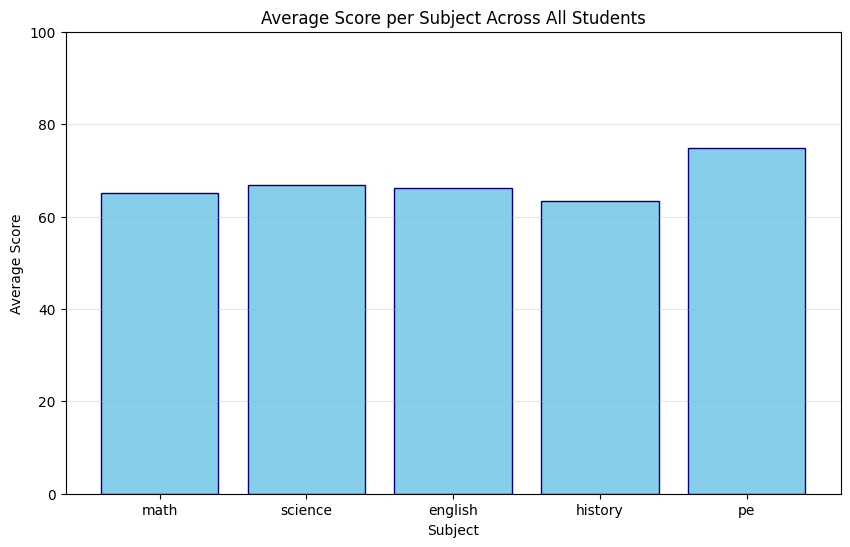

✅ Saved as 'plot1_bar.png'

Creating Plot 2: Histogram - Distribution of Math Scores...


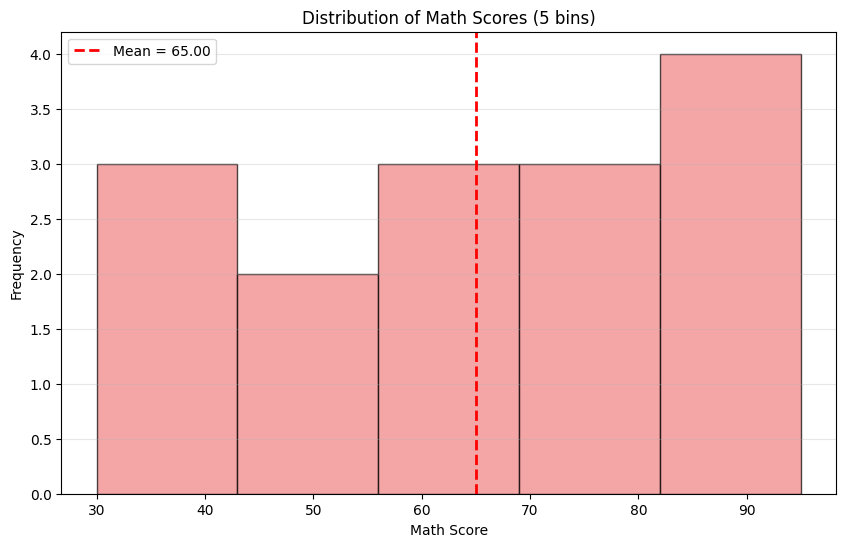

✅ Saved as 'plot2_histogram.png'

Creating Plot 3: Scatter Plot - Study Hours vs Average Score...


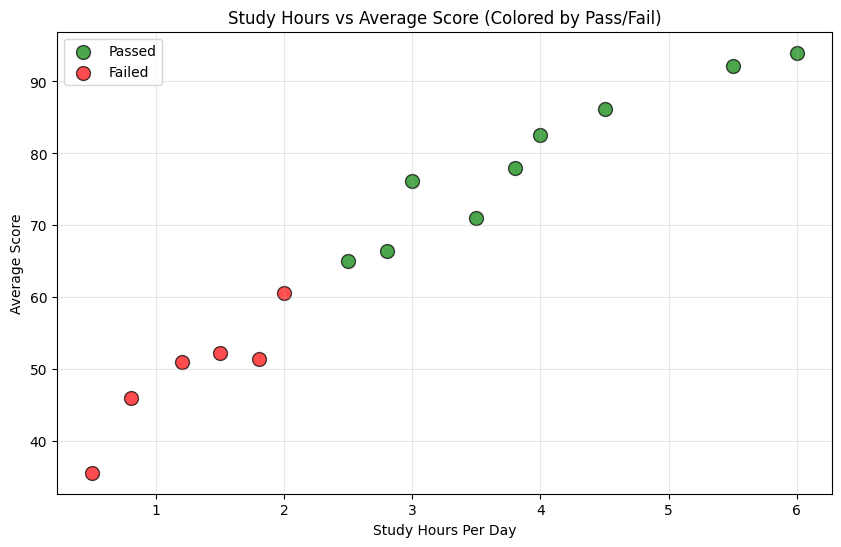

✅ Saved as 'plot3_scatter.png'

Creating Plot 4: Box Plot - Attendance Distribution (Pass vs Fail)...


C:\Users\nisha\AppData\Local\Temp\ipykernel_32100\1760502569.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance],


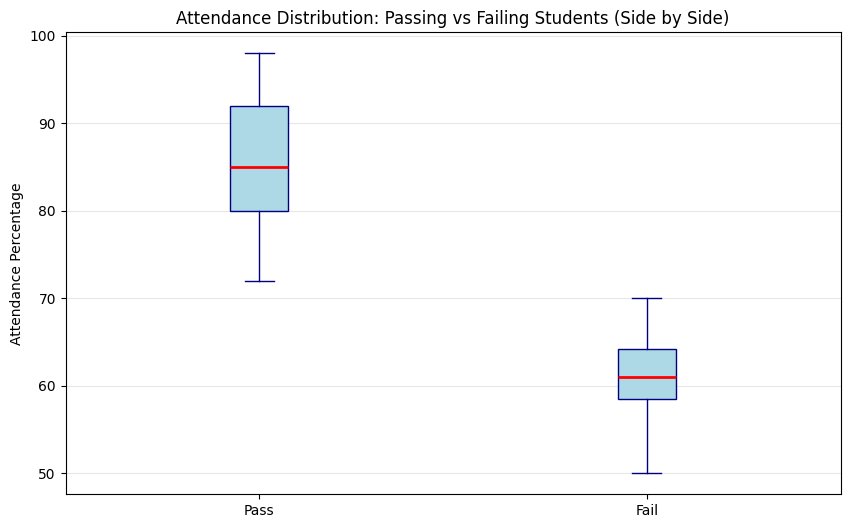

✅ Saved as 'plot4_boxplot.png'

Creating Plot 5: Line Plot - Math and Science Scores by Student...


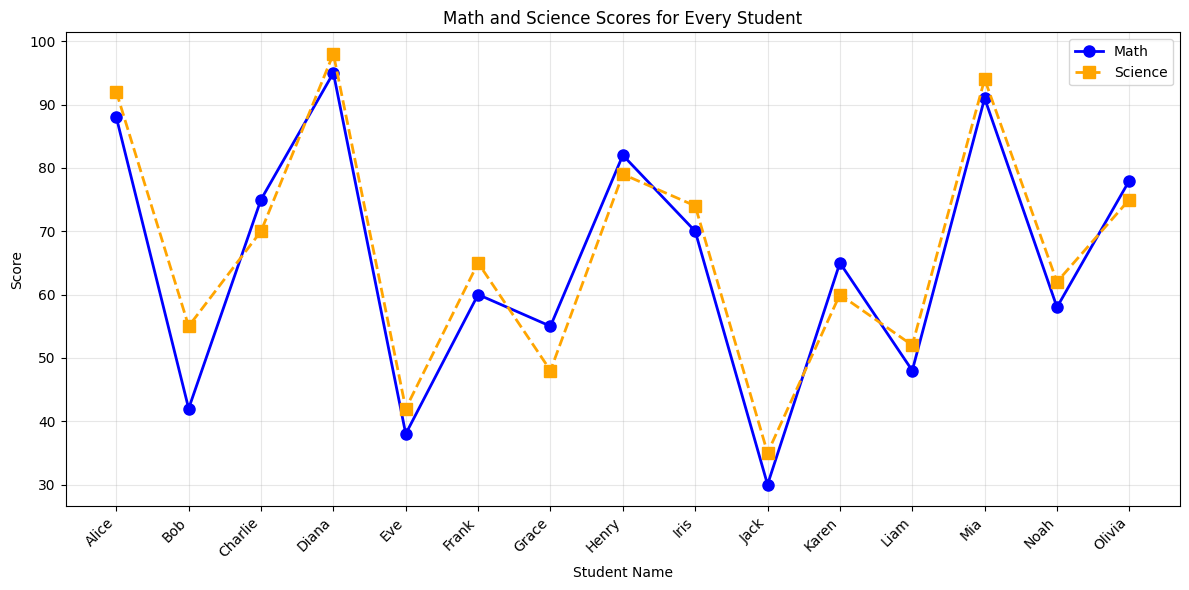

✅ Saved as 'plot5_lineplot.png'

All 5 plots created and saved successfully!


In [2]:
# Task 2 - Data Visualization with Matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*80)
print("Task 2 - Data Visualization with Matplotlib")
print("="*80 + "\n")

# Load the dataset (assuming it's already created from Task 1)
df = pd.read_csv("students.csv")

# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

print("✅ Added 'avg_score' column to DataFrame\n")

# Plot 1: Bar Chart - Average score per subject
print("Creating Plot 1: Bar Chart - Average score per subject...")

plt.figure(figsize=(10, 6))
subject_averages = df[subject_cols].mean()
plt.bar(subject_cols, subject_averages, color='skyblue', edgecolor='navy')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.title('Average Score per Subject Across All Students')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.savefig('plot1_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'plot1_bar.png'\n")

# Plot 2: Histogram - Distribution of math scores
print("Creating Plot 2: Histogram - Distribution of Math Scores...")

plt.figure(figsize=(10, 6))
mean_math = df['math'].mean()
plt.hist(df['math'], bins=5, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(mean_math, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_math:.2f}')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.title('Distribution of Math Scores (5 bins)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('plot2_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'plot2_histogram.png'\n")

# Plot 3: Scatter Plot - study_hours_per_day vs avg_score
print("Creating Plot 3: Scatter Plot - Study Hours vs Average Score...")

plt.figure(figsize=(10, 6))
passed_students = df[df['passed'] == 1]
failed_students = df[df['passed'] == 0]

plt.scatter(passed_students['study_hours_per_day'], passed_students['avg_score'], 
            color='green', label='Passed', s=100, alpha=0.7, edgecolors='black')
plt.scatter(failed_students['study_hours_per_day'], failed_students['avg_score'], 
            color='red', label='Failed', s=100, alpha=0.7, edgecolors='black')

plt.xlabel('Study Hours Per Day')
plt.ylabel('Average Score')
plt.title('Study Hours vs Average Score (Colored by Pass/Fail)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('plot3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'plot3_scatter.png'\n")

# Plot 4: Box Plot - Attendance distribution (Pass vs Fail)
print("Creating Plot 4: Box Plot - Attendance Distribution (Pass vs Fail)...")

plt.figure(figsize=(10, 6))
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], 
            labels=['Pass', 'Fail'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'))

plt.ylabel('Attendance Percentage')
plt.title('Attendance Distribution: Passing vs Failing Students (Side by Side)')
plt.grid(axis='y', alpha=0.3)
plt.savefig('plot4_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'plot4_boxplot.png'\n")

# Plot 5: Line Plot - Math and Science scores for every student
print("Creating Plot 5: Line Plot - Math and Science Scores by Student...")

plt.figure(figsize=(12, 6))
student_names = df['name'].tolist()
x_positions = range(len(student_names))

plt.plot(x_positions, df['math'], marker='o', linestyle='-', linewidth=2, 
         markersize=8, label='Math', color='blue')
plt.plot(x_positions, df['science'], marker='s', linestyle='--', linewidth=2, 
         markersize=8, label='Science', color='orange')

plt.xlabel('Student Name')
plt.ylabel('Score')
plt.title('Math and Science Scores for Every Student')
plt.xticks(x_positions, student_names, rotation=45, ha='right')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot5_lineplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'plot5_lineplot.png'\n")

print("="*80)
print("All 5 plots created and saved successfully!")
print("="*80)


Task 3 - Data Visualization with Seaborn

Creating Seaborn Plot 1: Bar Plot - Average Math & Science by Pass/Fail...


C:\Users\nisha\AppData\Local\Temp\ipykernel_32100\2888059543.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette=['red', 'green'])
C:\Users\nisha\AppData\Local\Temp\ipykernel_32100\2888059543.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Fail', 'Pass'])
C:\Users\nisha\AppData\Local\Temp\ipykernel_32100\2888059543.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette=['red', 'green'])
C:\Users\nisha\AppData\Local\Temp\ipykernel_32100\2888059543.py:39: UserWarning: set_ticklabels() sho

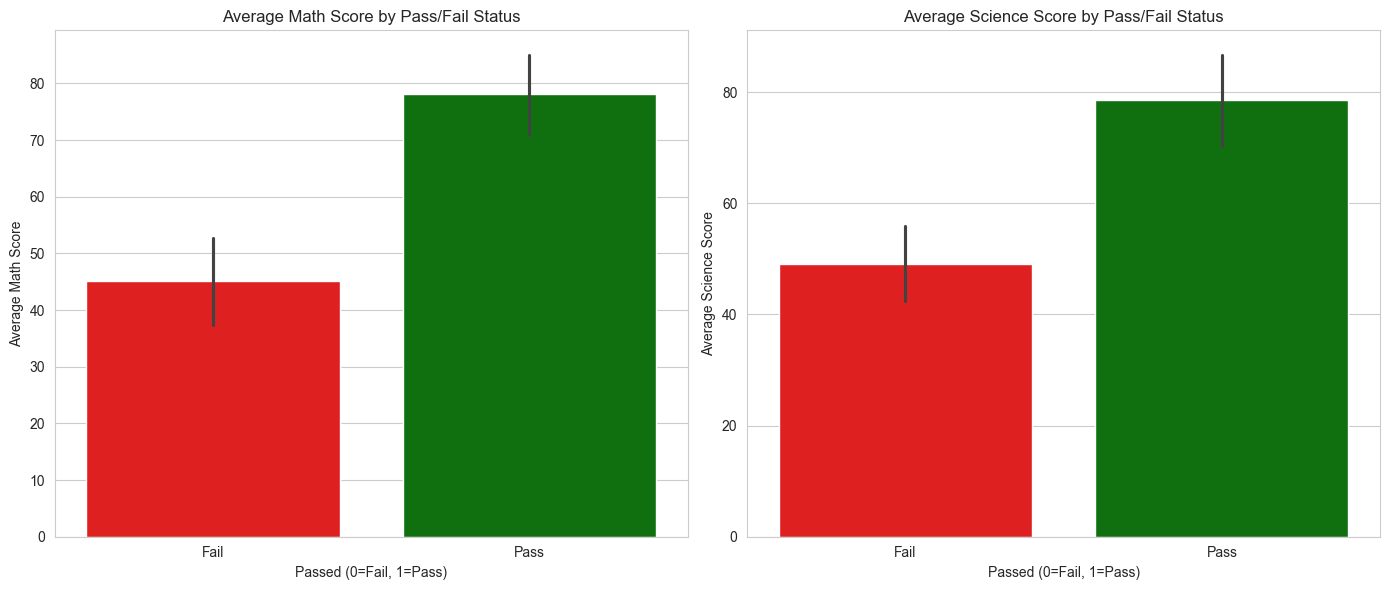

✅ Saved as 'seaborn_barplot.png'

Creating Seaborn Plot 2: Scatter Plot - Attendance vs Average Score...


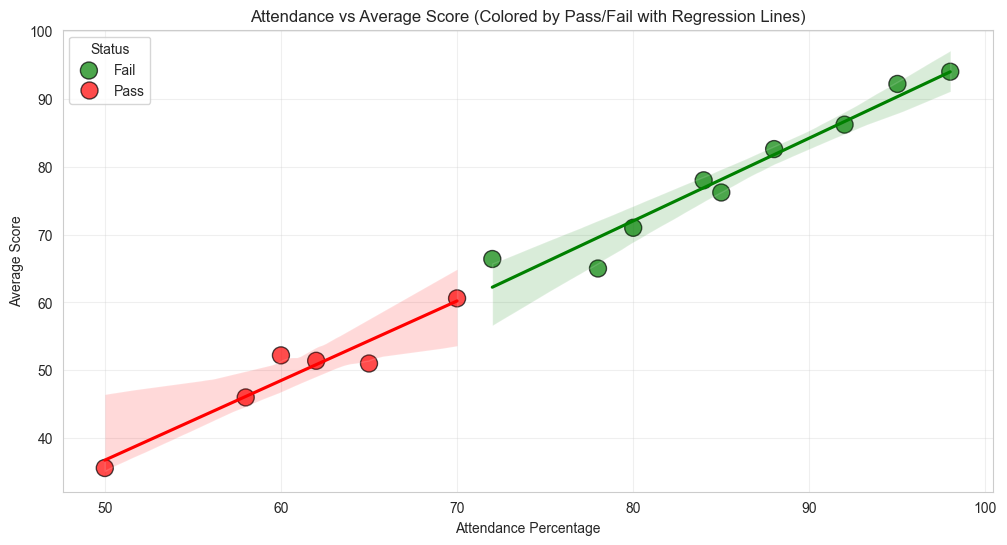

✅ Saved as 'seaborn_scatterplot.png'

All Seaborn plots created and saved successfully!

COMPARISON: Seaborn vs Matplotlib

Seaborn made creating the bar plots and scatter plots significantly easier compared 
to Matplotlib. With Seaborn, I could create grouped bar plots and add regression lines 
with just one or two function calls (sns.barplot() and sns.regplot()), whereas 
Matplotlib would have required manual calculation of averages, grouping data, and 
fitting regression lines. However, Seaborn required more work for customization of 
colors and labels compared to Matplotlib's more granular control. Overall, Seaborn 
is more efficient for statistical visualizations with built-in aesthetic defaults.



In [3]:
# Task 3 - Data Visualization with Seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("Task 3 - Data Visualization with Seaborn")
print("="*80 + "\n")

# Load the dataset
df = pd.read_csv("students.csv")

# Add avg_score column if not already present
subject_cols = ['math', 'science', 'english', 'history', 'pe']
if 'avg_score' not in df.columns:
    df['avg_score'] = df[subject_cols].mean(axis=1)

# Set seaborn style
sns.set_style("whitegrid")

# Plot 1: Seaborn Bar Plot - Average math and science scores split by passed
print("Creating Seaborn Plot 1: Bar Plot - Average Math & Science by Pass/Fail...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Math bar plot
sns.barplot(data=df, x='passed', y='math', ax=ax1, palette=['red', 'green'])
ax1.set_xlabel('Passed (0=Fail, 1=Pass)')
ax1.set_ylabel('Average Math Score')
ax1.set_title('Average Math Score by Pass/Fail Status')
ax1.set_xticklabels(['Fail', 'Pass'])

# Science bar plot
sns.barplot(data=df, x='passed', y='science', ax=ax2, palette=['red', 'green'])
ax2.set_xlabel('Passed (0=Fail, 1=Pass)')
ax2.set_ylabel('Average Science Score')
ax2.set_title('Average Science Score by Pass/Fail Status')
ax2.set_xticklabels(['Fail', 'Pass'])

plt.tight_layout()
plt.savefig('seaborn_barplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'seaborn_barplot.png'\n")

# Plot 2: Seaborn Scatter Plot - attendance_pct vs avg_score with regression lines
print("Creating Seaborn Plot 2: Scatter Plot - Attendance vs Average Score...")

plt.figure(figsize=(12, 6))

# Create scatter plot colored by passed
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed', 
                palette={0: 'red', 1: 'green'}, s=150, alpha=0.7, edgecolor='black')

# Add regression lines for each group
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', 
            scatter=False, label='Pass', color='green', ax=plt.gca())
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', 
            scatter=False, label='Fail', color='red', ax=plt.gca())

plt.xlabel('Attendance Percentage')
plt.ylabel('Average Score')
plt.title('Attendance vs Average Score (Colored by Pass/Fail with Regression Lines)')
plt.legend(title='Status', labels=['Fail', 'Pass'])
plt.grid(alpha=0.3)
plt.savefig('seaborn_scatterplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'seaborn_scatterplot.png'\n")

print("="*80)
print("All Seaborn plots created and saved successfully!")
print("="*80 + "\n")

# Comparison comments (2-3 sentences)
print("="*80)
print("COMPARISON: Seaborn vs Matplotlib")
print("="*80)
print("""
Seaborn made creating the bar plots and scatter plots significantly easier compared 
to Matplotlib. With Seaborn, I could create grouped bar plots and add regression lines 
with just one or two function calls (sns.barplot() and sns.regplot()), whereas 
Matplotlib would have required manual calculation of averages, grouping data, and 
fitting regression lines. However, Seaborn required more work for customization of 
colors and labels compared to Matplotlib's more granular control. Overall, Seaborn 
is more efficient for statistical visualizations with built-in aesthetic defaults.
""")
print("="*80)


Task 4 - Machine Learning with scikit-learn

Dataset loaded successfully!

STEP 1: PREPARE DATA

Features (X): ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
Target (y): passed

X shape: (15, 7)
y shape: (15,)

Training set: 12 samples
Test set: 3 samples

✅ Features scaled using StandardScaler

STEP 2: TRAIN A MODEL

✅ Logistic Regression model trained

Training Accuracy: 100.00%

STEP 3: EVALUATE THE MODEL

Test Accuracy: 100.00%

Test Set Predictions:

Name         | Actual   | Predicted  | Result
--------------------------------------------------
Jack         | Fail     | Fail       | ✅ Correct
Liam         | Fail     | Fail       | ✅ Correct
Alice        | Pass     | Pass       | ✅ Correct

Note: With only 3 test samples (15 × 20% = 3), the test accuracy will be
either 0%, 33%, 66%, or 100% — all valid outcomes for such a small dataset.
The goal is to understand the ML workflow, not optimize accuracy.

STEP 4: FEATURE IMPORTANCE

Feature 

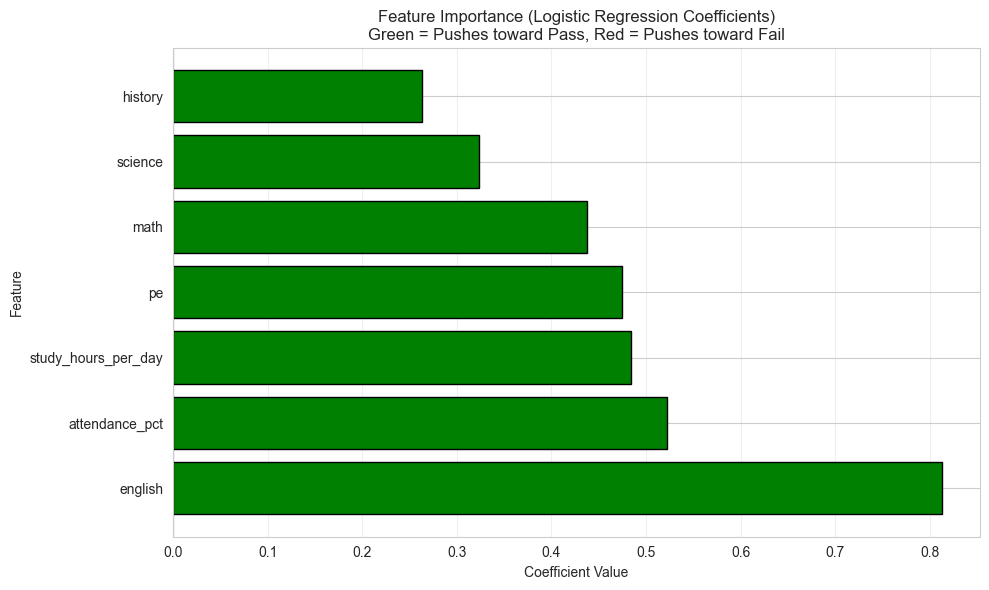

✅ Feature importance chart saved as 'feature_importance.png'

STEP 5: PREDICT FOR A NEW STUDENT (BONUS)

New student data:
  math: 75
  science: 70
  english: 68
  history: 65
  pe: 80
  attendance_pct: 82
  study_hours_per_day: 3.2

🔮 Model Prediction: Pass

Prediction Probabilities:
  Fail (0): 9.20%
  Pass (1): 90.80%

Machine Learning Pipeline Complete!


c:\Users\nisha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [4]:
# Task 4 - Machine Learning with scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("\n" + "="*80)
print("Task 4 - Machine Learning with scikit-learn")
print("="*80 + "\n")

# Load the dataset
df = pd.read_csv("students.csv")

print("Dataset loaded successfully!\n")

# Step 1 - Prepare Data

print("="*80)
print("STEP 1: PREPARE DATA")
print("="*80 + "\n")

# Define features (X) and target (y)
feature_cols = ['math', 'science', 'english', 'history', 'pe', 
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]  # Keep original df intact
y = df['passed']

print(f"Features (X): {feature_cols}")
print(f"Target (y): passed\n")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}\n")

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples\n")

# Scale features using StandardScaler (fit on training data only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler\n")

# Step 2 - Train a Model

print("="*80)
print("STEP 2: TRAIN A MODEL")
print("="*80 + "\n")

# Train LogisticRegression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression model trained\n")

# Print training accuracy
y_train_pred = model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2%}\n")

# Step 3 - Evaluate the Model

print("="*80)
print("STEP 3: EVALUATE THE MODEL")
print("="*80 + "\n")

# Predict on test set
y_test_pred = model.predict(X_test_scaled)

# Print test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.2%}\n")

# Print predictions for each test student
print("Test Set Predictions:\n")
print(f"{'Name':<12} | {'Actual':<8} | {'Predicted':<10} | {'Result'}")
print("-" * 50)

# Get original indices from X_test to retrieve student names
for idx in X_test.index:
    student_name = df.loc[idx, 'name']
    actual = y_test.loc[idx]
    predicted = y_test_pred[list(X_test.index).index(idx)]
    
    if actual == predicted:
        result = "✅ Correct"
    else:
        result = "❌ Wrong"
    
    actual_label = "Pass" if actual == 1 else "Fail"
    predicted_label = "Pass" if predicted == 1 else "Fail"
    
    print(f"{student_name:<12} | {actual_label:<8} | {predicted_label:<10} | {result}")

print("\n" + "="*80)
print("Note: With only 3 test samples (15 × 20% = 3), the test accuracy will be")
print("either 0%, 33%, 66%, or 100% — all valid outcomes for such a small dataset.")
print("The goal is to understand the ML workflow, not optimize accuracy.")
print("="*80 + "\n")

# Step 4 - Feature Importance

print("="*80)
print("STEP 4: FEATURE IMPORTANCE")
print("="*80 + "\n")

# Extract model coefficients
coefficients = model.coef_[0]

# Pair each coefficient with its feature name
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value (largest first)
feature_importance_sorted = sorted(feature_importance, key=lambda x: abs(x[1]), reverse=True)

print("Feature Coefficients (sorted by absolute value):\n")
for feature, coef in feature_importance_sorted:
    print(f"  {feature:<25}: {coef:>8.4f}")

print("\n")

# Create horizontal bar chart
features = [f[0] for f in feature_importance_sorted]
coefs = [f[1] for f in feature_importance_sorted]
colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure(figsize=(10, 6))
plt.barh(features, coefs, color=colors, edgecolor='black')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance (Logistic Regression Coefficients)\nGreen = Pushes toward Pass, Red = Pushes toward Fail')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved as 'feature_importance.png'\n")

# Step 5 - Predict for a New Student (Bonus)

print("="*80)
print("STEP 5: PREDICT FOR A NEW STUDENT (BONUS)")
print("="*80 + "\n")

# Define new student (values must match feature columns order)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]  # math, science, english, history, pe, attendance_pct, study_hours_per_day

print("New student data:")
for i, feature in enumerate(feature_cols):
    print(f"  {feature}: {new_student[0][i]}")

# Scale the new student data
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)[0]
prediction_proba = model.predict_proba(new_student_scaled)[0]

print(f"\n🔮 Model Prediction: {'Pass' if prediction == 1 else 'Fail'}")
print(f"\nPrediction Probabilities:")
print(f"  Fail (0): {prediction_proba[0]:.2%}")
print(f"  Pass (1): {prediction_proba[1]:.2%}")

print("\n" + "="*80)
print("Machine Learning Pipeline Complete!")
print("="*80)